# Post-stall transient
The theory of post-stall transient, as described by Moore and Greitzer (A Theory of Post-Stall Transients in Axial Compression Systems: Part I—Development of Equations, 1986)

### import

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

### Input data
data taken from the example calculations showns in the article (part II), who took data from (Stalled flow performance for axial compressors - I: axisymmetric characteristic - Koof, Greitzer).
* $B = 0.5$  leads to rotating stall
* $B = 1$  leads to surge stall

In [2]:
B = 3  # B parameter of the described compressor, rotating stall
# B = 1  # B parameter of the described compressor, surge 
lc = 8  # non-dimensional compressor duct length
phi_eq = 0.5  # initial flow coefficient for all the calculations
k_valve = 5.5  # valve characteristic
m = 1.75  # Moore parameter
a_lag = 1 / 3.5  # lag parameter, defined by Moore

### Unstalled characteristic definition
definition of the unstalled compressor characteristic, following the cubic model as described in the paper

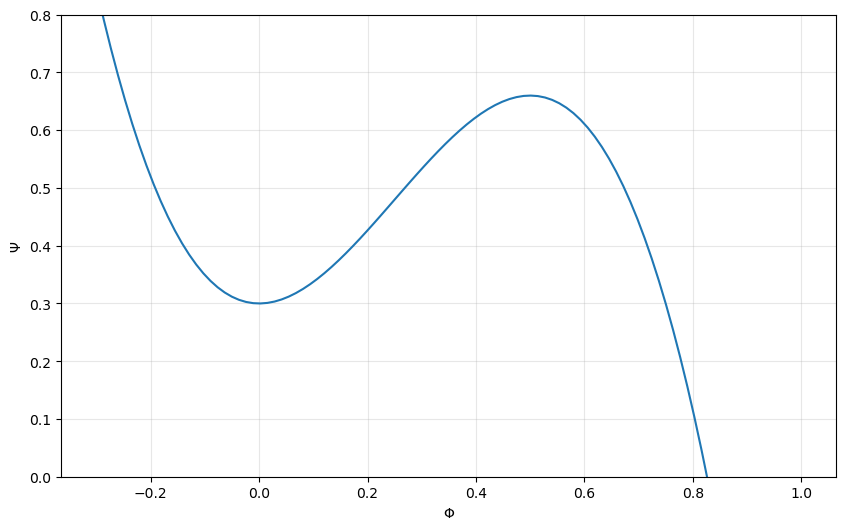

In [3]:
# domain of flow coefficient
phi = np.linspace(-0.3, 1, 100)

# parameters of the cubic curve, taken from the article part II
H = 0.18
W = 0.25
psi_c_max = 0.66  # section 3 of paper
phi_c_max = 0.5
psi_c_0 = psi_c_max - 2 * H

def unstalled_characteristic(phi):
    """
    Arguments:
        phi :  flow coefficient
        H : H parameter
        W : W parameter
        psi_c_0 : performance at zero flow coefficient
    """
    return psi_c_0 + H * (1 + 1.5 * (phi / W - 1) - 0.5 * (phi / W - 1) ** 3)

psi_c = unstalled_characteristic(phi)

plt.figure(figsize=(10,6))
plt.plot(phi, psi_c, label='unstalled characteristic')
# plt.xlim([0, 0.9])
plt.ylim([0, 0.8])
plt.xlabel(r'$\Phi$')
plt.ylabel(r'$\Psi$')
# plt.legend()
plt.grid(alpha=0.3)
plt.savefig('cubic_compressor_curve.pdf', bbox_inches = 'tight')

### Valve characteristic definition
definition of the valve characteristic as a square function of the mass flow rate. Find the valve constant imposing the initial operating point at the peak of the characteristic

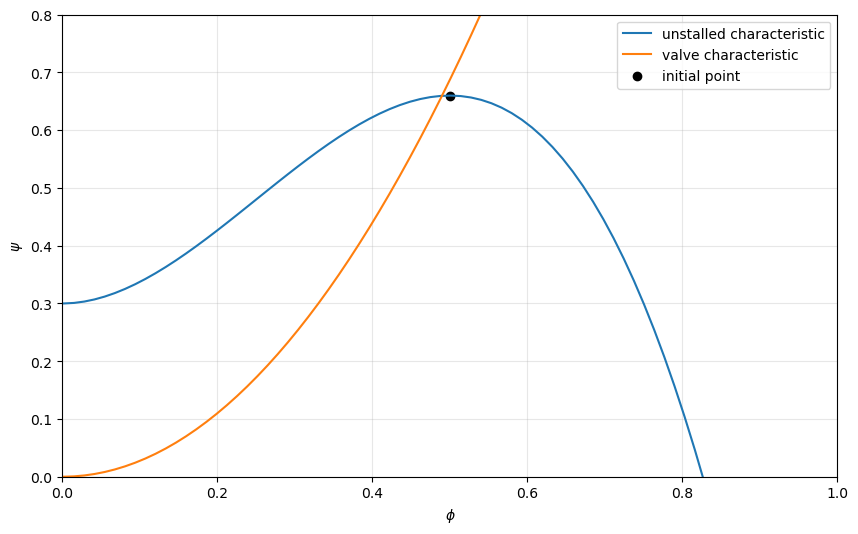

In [4]:
psi_eq = unstalled_characteristic(phi_eq)
psi_v = 0.5 *k_valve * phi ** 2  # valve model

plt.figure(figsize=(10,6))
plt.plot(phi, psi_c, label='unstalled characteristic')
plt.plot(phi, psi_v, label='valve characteristic')
plt.scatter(phi_eq, psi_eq, c='black', label='initial point')
plt.xlim([0, 1])
plt.ylim([0, 0.8])
plt.xlabel(r'$\phi$')
plt.ylabel(r'$\psi$')
plt.legend()
plt.grid(alpha=0.3)

### Moore-Greitzer governing equations
define the governing equations of the Moore-Greitzer system

In [5]:
def Moore_Greitzer(y, xi, B, k_valve, W, H, psi_c_0, a, m, lc):
    """
    Defines the differential equations for the Greitzer model
    (as found in the thesis of Sündstrom).

    Arguments:
        y :  vector of the state variables
        xi : non dimensional time
        B :  B parameter
        k_valve :  throttle line coefficient
        W : W parameter of cubic shape of compressor 
        H : H parameter of cubic shape of compressor
        psi_c_0 : work coefficient at zero flow rate parameter of cubic shape
        a : reciprocal time lag
        m : duct parameter, between 1 and 2
        lc : non dimensional compressor length
        
    State variables:
        x1 : total to static work coefficient \Psi
        x2 : azimuthally averaged flow coefficient \Phi
        x3 : squared amplitude of rotating stall cell J
    """
    x1, x2, x3 = y
    dydt = [W / (4 * lc * B ** 2) * (x2 / W - (1 / W) * np.sqrt(x1 / k_valve)),
            (H / lc) * (-(x1 - psi_c_0) / H + 1 + 1.5 * (x2 / W - 1) * (1 - 0.5 * x3) - 0.5 * (x2 / W - 1) ** 3),
            x3 * (1 - (x2 / W - 1) ** 2 - 0.25 * x3) * (3 * a * H) / (W * (1 + m * a))]
    return dydt

### set up the problem to be solved

In [6]:
xi = np.linspace(0, 2000, 10000)
A_0 = 0.005 / W

# initial conditions
A_0 = 0.2 
J_0 = A_0 ** 2
y0 = [psi_eq,
      phi_eq,
      J_0]

### solve the system

In [7]:
from scipy.integrate import odeint
sol = odeint(Moore_Greitzer, y0, xi, args=(B, k_valve, W, H, psi_c_0, a_lag, m, lc))
psi_sol = sol[:, 0]
phi_sol = sol[:, 1]
J_sol = sol[:, 2]

### Plot the perturbations in time domain

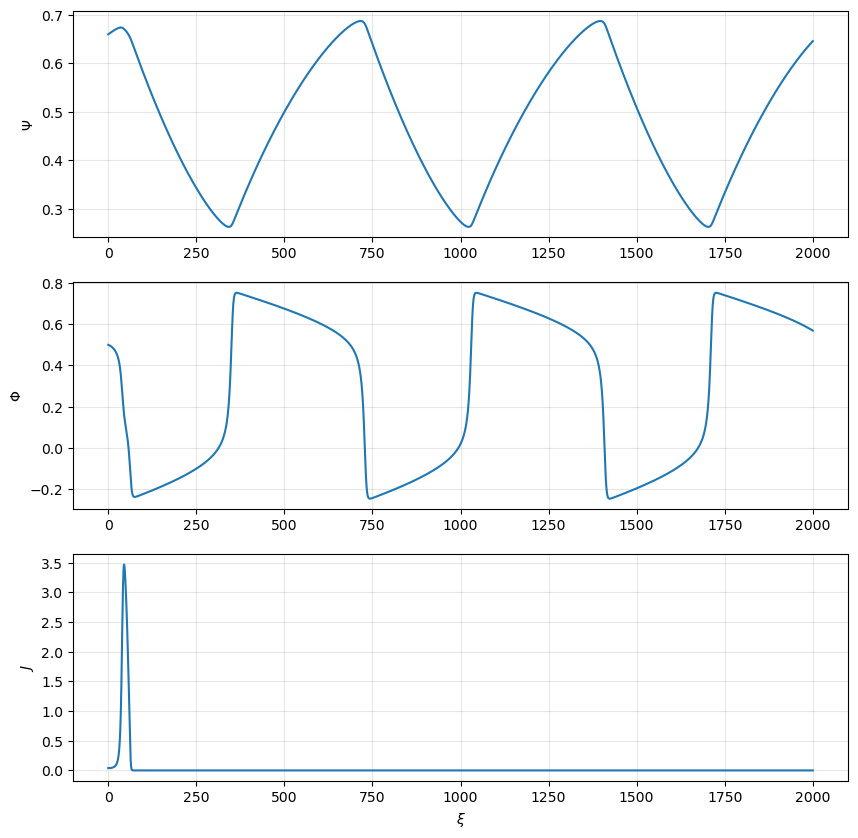

In [8]:
# temporal evolution plots
fig, axes = plt.subplots(3, 1, figsize=(10,10))
axes[0].set_ylabel(r'$\Psi$')
axes[0].plot(xi, psi_sol)
axes[0].grid(alpha=0.3)
axes[1].set_ylabel(r'$\Phi$')
axes[1].plot(xi, phi_sol)
axes[1].grid(alpha=0.3)
axes[2].set_ylabel(r'$J$')
axes[2].plot(xi, J_sol)
axes[2].set_xlabel(r'$\xi $')
axes[2].grid(alpha=0.3)
# plt.savefig('stall_time_perturbations.pdf', bbox_inches='tight')

### Phase-space trajectory
plot flow and work coefficient trajectory in the phase-space, superposed to the compressor and throttle valve characteristic

(0.17751683876020713, 0.7724420010444207)

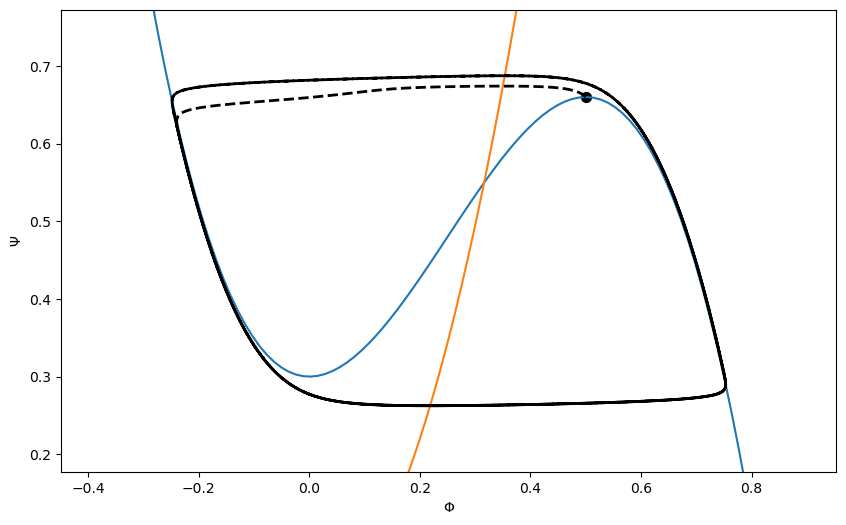

In [ ]:
# find limits for the next plot
phi_min = np.min(phi_sol)
phi_max = np.max(phi_sol)
psi_min = np.min(psi_sol)
psi_max = np.max(psi_sol)
c = 0.2
lim_phi = [phi_min - c * (phi_max - phi_min), 
          phi_max + c * (phi_max - phi_min)]
lim_psi = [psi_min - c * (psi_max - psi_min), 
          psi_max + c * (psi_max - psi_min)]

# plot
plt.figure(figsize=(10, 6))
plt.plot(phi, psi_c, label='unstalled characteristic')
plt.plot(phi[phi>0], k_valve * phi[phi>0] ** 2, label='throttle characteristic')
plt.plot(phi_sol, psi_sol, '--k', lw = 2, label='transient')
plt.scatter(phi_sol[0], psi_sol[0], c='black', marker = 'o', s =50, label='initial point')
# plt.scatter(phi_sol[-1], psi_sol[-1], c='black', marker = 's', s= 50,  label='final point')
plt.ylabel(r'$\Psi$')
plt.xlabel(r'$\Phi$')
# plt.legend()
plt.xlim(lim_phi)
plt.ylim(lim_psi)
plt.savefig('deep_surge_trajectory.pdf', bbox_inches='tight')